✓ All libraries imported successfully!

Loading dataset from Google Drive...
✓ Dataset loaded successfully!
Shape: (32561, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

DATA EXPLORATION

First 5 rows:
   age          workclass  fnlwgt   education  education_num   
0   39          State-gov   77516   Bachelors             13  \
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex   
0        Never-married        Adm-clerical   Not-in-family   White     Male  \
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2      

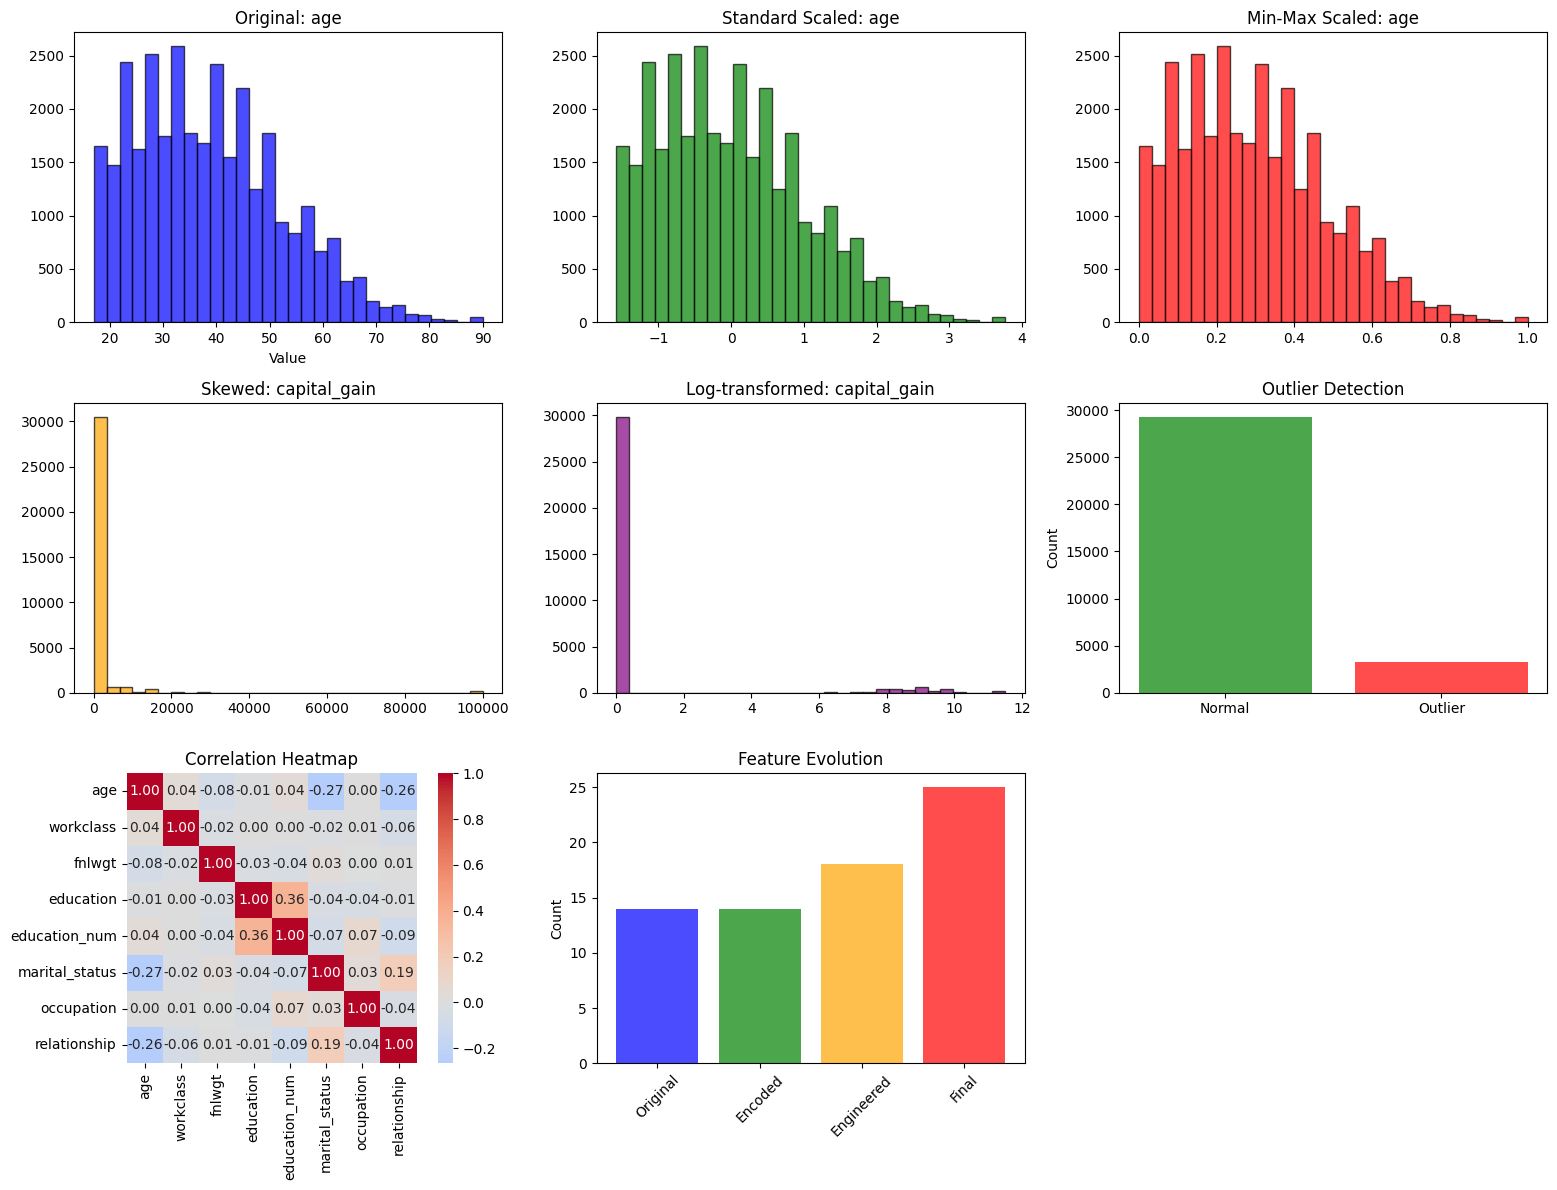


DOWNLOADING FILES
⚠ Could not download adult_processed.csv
⚠ Could not download adult_final.csv
⚠ Could not download adult_standard_scaled.csv
⚠ Could not download adult_minmax_scaled.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: data_transformation_analysis.png

SUMMARY REPORT

✅ DATA TRANSFORMATION COMPLETE!

Original Shape: (32561, 15)
Final Shape: (32561, 25)
Target: income

COMPLETED TASKS:
✓ Missing value handling
✓ Standard & Min-Max scaling
✓ One-Hot encoding (1 features)
✓ Label encoding (7 features)
✓ Feature engineering (4 new features)
✓ Log transformation (6 features)
✓ Outlier detection (3256 outliers)
✓ Feature importance analysis

FILES READY FOR DOWNLOAD:
📁 adult_processed.csv
📁 adult_final.csv
📁 adult_standard_scaled.csv
📁 adult_minmax_scaled.csv
📊 data_transformation_analysis.png

🎉 Assignment Complete!


✓ All tasks finished successfully!


In [15]:
# Adult Dataset - Complete Data Transformation Assignment
# Google Colab - Direct Download Version

# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print("✓ All libraries imported successfully!")

# ============================================================================
# 2. LOAD DATASET
# ============================================================================

# Load dataset directly from Google Drive link
file_id = "1hLNVXbCXRIhokjVdSDXnVmRcuACB5x9Z"
url = f"https://drive.google.com/uc?id={file_id}"

print("\nLoading dataset from Google Drive...")
df = pd.read_csv(url)

print("✓ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# ============================================================================
# 3. DATA EXPLORATION
# ============================================================================

print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

# ============================================================================
# 4. HANDLE MISSING VALUES
# ============================================================================

print("\n" + "="*80)
print("HANDLING MISSING VALUES")
print("="*80)

# Replace '?' with NaN
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()
        df[col] = df[col].replace('?', np.nan)

print("\nMissing values found:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Impute missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"✓ Imputed '{col}' with mode")
        else:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"✓ Imputed '{col}' with median")

print(f"\n✓ Missing values after imputation: {df.isnull().sum().sum()}")

# ============================================================================
# 5. SEPARATE FEATURES AND TARGET
# ============================================================================

# Find target column
target_candidates = [col for col in df.columns if 'income' in col.lower()]
if target_candidates:
    target_col = target_candidates[0]
else:
    target_col = df.columns[-1]

y = df[target_col].copy()
X = df.drop(columns=[target_col])

print(f"\n✓ Target: '{target_col}'")

# Identify feature types
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"✓ Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"✓ Categorical features ({len(categorical_features)}): {categorical_features}")

# ============================================================================
# 6. SCALING TECHNIQUES
# ============================================================================

print("\n" + "="*80)
print("SCALING TECHNIQUES")
print("="*80)

# Standard Scaling
X_standard = X.copy()
scaler_std = StandardScaler()
X_standard[numerical_features] = scaler_std.fit_transform(X[numerical_features])
print("\n✓ Standard Scaling applied")
print(X_standard[numerical_features].describe().round(3))

# Min-Max Scaling
X_minmax = X.copy()
scaler_mm = MinMaxScaler()
X_minmax[numerical_features] = scaler_mm.fit_transform(X[numerical_features])
print("\n✓ Min-Max Scaling applied")
print(X_minmax[numerical_features].describe().round(3))

print("""
\nWHEN TO USE:
Standard Scaling: Normal distribution, SVM, Neural Networks, KNN
Min-Max Scaling: Bounded values needed, Neural Networks, Image processing
""")

# ============================================================================
# 7. ENCODING TECHNIQUES
# ============================================================================

print("\n" + "="*80)
print("ENCODING TECHNIQUES")
print("="*80)

# Categorize by cardinality
low_card = []
high_card = []

for col in categorical_features:
    n = X[col].nunique()
    print(f"{col}: {n} unique values")
    if n < 5:
        low_card.append(col)
    else:
        high_card.append(col)

print(f"\n✓ Low cardinality: {low_card}")
print(f"✓ High cardinality: {high_card}")

# Encoding
X_encoded = X.copy()

# One-Hot Encoding
if low_card:
    X_encoded = pd.get_dummies(X_encoded, columns=low_card, drop_first=True)
    print(f"\n✓ One-Hot Encoding applied to: {low_card}")

# Label Encoding
label_encoders = {}
for col in high_card:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"✓ Label Encoding applied to: {col}")

print(f"\n✓ Shape after encoding: {X_encoded.shape}")

# ============================================================================
# 8. FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

X_engineered = X_encoded.copy()
new_features = []

# Feature 1: Age groups
if 'age' in X.columns:
    X_engineered['age_group'] = pd.cut(X['age'],
                                       bins=[0, 25, 35, 50, 65, 100],
                                       labels=[0, 1, 2, 3, 4])
    X_engineered['age_group'] = X_engineered['age_group'].astype(int)
    new_features.append('age_group')
    print("✓ Created: age_group")

# Feature 2: Work intensity
hours_col = [c for c in X.columns if 'hour' in c.lower()]
if hours_col:
    X_engineered['work_intensity'] = pd.cut(X[hours_col[0]],
                                           bins=[0, 20, 40, 60, 100],
                                           labels=[0, 1, 2, 3])
    X_engineered['work_intensity'] = X_engineered['work_intensity'].astype(int)
    new_features.append('work_intensity')
    print("✓ Created: work_intensity")

# Feature 3: Education-Age ratio
if 'age' in X.columns:
    edu_cols = [c for c in X.columns if 'education' in c.lower() and 'num' in c.lower()]
    if edu_cols:
        X_engineered['edu_age_ratio'] = X[edu_cols[0]] / (X['age'] + 1)
        new_features.append('edu_age_ratio')
        print("✓ Created: edu_age_ratio")

# Feature 4: Capital activity
cap_gain = [c for c in X.columns if 'capital' in c.lower() and 'gain' in c.lower()]
cap_loss = [c for c in X.columns if 'capital' in c.lower() and 'loss' in c.lower()]
if cap_gain and cap_loss:
    X_engineered['has_capital'] = ((X[cap_gain[0]] > 0) | (X[cap_loss[0]] > 0)).astype(int)
    new_features.append('has_capital')
    print("✓ Created: has_capital")

print(f"\n✓ Total new features: {len(new_features)}")

# ============================================================================
# 9. LOG TRANSFORMATION
# ============================================================================

print("\n" + "="*80)
print("LOG TRANSFORMATION")
print("="*80)

# Get numerical columns
num_cols = X_engineered.select_dtypes(include=['int64', 'float64']).columns
skewness = X_engineered[num_cols].skew().sort_values(ascending=False)

print("\nSkewness:")
print(skewness.head(10).round(3))

# Transform highly skewed
highly_skewed = skewness[abs(skewness) > 1].index.tolist()
print(f"\n✓ Highly skewed: {highly_skewed}")

X_transformed = X_engineered.copy()
for feat in highly_skewed:
    if X_transformed[feat].min() >= 0:
        X_transformed[f'{feat}_log'] = np.log1p(X_transformed[feat])
        print(f"✓ Log-transformed: {feat}")

# ============================================================================
# 10. ISOLATION FOREST
# ============================================================================

print("\n" + "="*80)
print("OUTLIER DETECTION")
print("="*80)

# Prepare data
num_for_iso = [c for c in X_transformed.columns
               if X_transformed[c].dtype in ['int64', 'float64']]
X_iso = X_transformed[num_for_iso].fillna(0)

# Detect outliers
iso = IsolationForest(contamination=0.1, random_state=42)
outliers = iso.fit_predict(X_iso)

X_transformed['is_outlier'] = (outliers == -1).astype(int)

n_outliers = (outliers == -1).sum()
print(f"\n✓ Outliers detected: {n_outliers} ({n_outliers/len(X_iso)*100:.2f}%)")

# ============================================================================
# 11. FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE")
print("="*80)

# Correlation
print("\n--- Correlation Analysis ---")
corr = X_transformed[num_for_iso].corr()

high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            high_corr.append({
                'Feature_1': corr.columns[i],
                'Feature_2': corr.columns[j],
                'Correlation': round(corr.iloc[i, j], 3)
            })

if high_corr:
    print(pd.DataFrame(high_corr))
else:
    print("No highly correlated pairs found")

# Mutual Information
print("\n--- Mutual Information ---")
try:
    y_enc = LabelEncoder().fit_transform(y.astype(str))
    mi = mutual_info_classif(X_transformed[num_for_iso], y_enc, random_state=42)
    mi_df = pd.DataFrame({'Feature': num_for_iso, 'MI_Score': mi}).sort_values('MI_Score', ascending=False)
    print(mi_df.head(10))
except:
    print("Could not calculate MI")

# ============================================================================
# 12. SAVE AND DOWNLOAD FILES
# ============================================================================

print("\n" + "="*80)
print("SAVING FILES")
print("="*80)

from google.colab import files

# Prepare clean DataFrames
def clean_df(df):
    """Clean DataFrame for CSV export"""
    df_clean = pd.DataFrame(df)
    df_clean.columns = [str(c) for c in df_clean.columns]
    return df_clean

# Save files
print("\nCreating files...")

try:
    # File 1: Processed data
    df1 = clean_df(X_transformed)
    df1.to_csv('adult_processed.csv', index=False)
    print("✓ adult_processed.csv")

    # File 2: With target
    df2 = clean_df(X_transformed)
    df2[target_col] = y.values
    df2.to_csv('adult_final.csv', index=False)
    print("✓ adult_final.csv")

    # File 3: Standard scaled
    df3 = clean_df(X_standard[numerical_features])
    df3.to_csv('adult_standard_scaled.csv', index=False)
    print("✓ adult_standard_scaled.csv")

    # File 4: MinMax scaled
    df4 = clean_df(X_minmax[numerical_features])
    df4.to_csv('adult_minmax_scaled.csv', index=False)
    print("✓ adult_minmax_scaled.csv")

except Exception as e:
    print(f"Error creating files: {e}")

# ============================================================================
# 13. VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(16, 12))

# Plot 1-3: Scaling comparison
if len(numerical_features) > 0:
    feat = numerical_features[0]

    plt.subplot(3, 3, 1)
    plt.hist(X[feat], bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f'Original: {feat}')
    plt.xlabel('Value')

    plt.subplot(3, 3, 2)
    plt.hist(X_standard[feat], bins=30, alpha=0.7, color='green', edgecolor='black')
    plt.title(f'Standard Scaled: {feat}')

    plt.subplot(3, 3, 3)
    plt.hist(X_minmax[feat], bins=30, alpha=0.7, color='red', edgecolor='black')
    plt.title(f'Min-Max Scaled: {feat}')

# Plot 4-5: Skewed vs Log
if highly_skewed:
    feat = highly_skewed[0]

    plt.subplot(3, 3, 4)
    plt.hist(X_engineered[feat], bins=30, alpha=0.7, color='orange', edgecolor='black')
    plt.title(f'Skewed: {feat}')

    plt.subplot(3, 3, 5)
    if f'{feat}_log' in X_transformed.columns:
        plt.hist(X_transformed[f'{feat}_log'], bins=30, alpha=0.7, color='purple', edgecolor='black')
        plt.title(f'Log-transformed: {feat}')

# Plot 6: Outliers
plt.subplot(3, 3, 6)
outlier_counts = X_transformed['is_outlier'].value_counts()
plt.bar(['Normal', 'Outlier'], outlier_counts.values, color=['green', 'red'], alpha=0.7)
plt.title('Outlier Detection')
plt.ylabel('Count')

# Plot 7: Correlation heatmap
plt.subplot(3, 3, 7)
top_feat = num_for_iso[:8] if len(num_for_iso) > 8 else num_for_iso
if len(top_feat) > 1:
    sns.heatmap(X_transformed[top_feat].corr(), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True)
    plt.title('Correlation Heatmap')

# Plot 8: Feature counts
plt.subplot(3, 3, 8)
counts = {
    'Original': len(X.columns),
    'Encoded': len(X_encoded.columns),
    'Engineered': len(X_engineered.columns),
    'Final': len(X_transformed.columns)
}
plt.bar(counts.keys(), counts.values(), color=['blue', 'green', 'orange', 'red'], alpha=0.7)
plt.title('Feature Evolution')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('data_transformation_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved")
plt.show()

# ============================================================================
# 14. DOWNLOAD ALL FILES
# ============================================================================

print("\n" + "="*80)
print("DOWNLOADING FILES")
print("="*80)

try:
    files.download('adult_processed.csv')
    print("✓ Downloaded: adult_processed.csv")
except:
    print("⚠ Could not download adult_processed.csv")

try:
    files.download('adult_final.csv')
    print("✓ Downloaded: adult_final.csv")
except:
    print("⚠ Could not download adult_final.csv")

try:
    files.download('adult_standard_scaled.csv')
    print("✓ Downloaded: adult_standard_scaled.csv")
except:
    print("⚠ Could not download adult_standard_scaled.csv")

try:
    files.download('adult_minmax_scaled.csv')
    print("✓ Downloaded: adult_minmax_scaled.csv")
except:
    print("⚠ Could not download adult_minmax_scaled.csv")

try:
    files.download('data_transformation_analysis.png')
    print("✓ Downloaded: data_transformation_analysis.png")
except:
    print("⚠ Could not download visualization")

# ============================================================================
# 15. SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SUMMARY REPORT")
print("="*80)

print(f"""
✅ DATA TRANSFORMATION COMPLETE!

Original Shape: {df.shape}
Final Shape: {X_transformed.shape}
Target: {target_col}

COMPLETED TASKS:
✓ Missing value handling
✓ Standard & Min-Max scaling
✓ One-Hot encoding ({len(low_card)} features)
✓ Label encoding ({len(high_card)} features)
✓ Feature engineering ({len(new_features)} new features)
✓ Log transformation ({len(highly_skewed)} features)
✓ Outlier detection ({n_outliers} outliers)
✓ Feature importance analysis

FILES READY FOR DOWNLOAD:
📁 adult_processed.csv
📁 adult_final.csv
📁 adult_standard_scaled.csv
📁 adult_minmax_scaled.csv
📊 data_transformation_analysis.png

🎉 Assignment Complete!
""")

print("\n✓ All tasks finished successfully!")